# 03 Exploratory Data Analysis (EDA)

## Objective
Analyze sales trends, inventory patterns, prescription distribution, and employee performance directly from CSV data without `src` module dependencies.

## Visualizations Included
- Daily sales trend
- Inventory levels and usage rate by drug
- Prescription distribution
- Employee metrics distribution

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

candidate_roots = [Path.cwd(), Path.cwd().parent]
project_root = next((p for p in candidate_roots if (p / 'data').exists()), None)
if project_root is None:
    raise FileNotFoundError('Could not locate data folder. Run from project root or notebooks folder.')

data_dir = project_root / 'data'

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f'Project Root: {project_root}')
print(f'Data Directory: {data_dir}')

Project Root: D:\projects\ai-ml-projects\PharmaEase_correct\pharma_ease_ai
Data Directory: D:\projects\ai-ml-projects\PharmaEase_correct\pharma_ease_ai\data


In [2]:
inventory = pd.read_csv(data_dir / 'inventory.csv')
sales = pd.read_csv(data_dir / 'sales.csv')
prescriptions = pd.read_csv(data_dir / 'prescriptions.csv')
employees = pd.read_csv(data_dir / 'employees.csv')

print('Datasets loaded successfully')
print({
    'inventory': inventory.shape,
    'sales': sales.shape,
    'prescriptions': prescriptions.shape,
    'employees': employees.shape
})

Datasets loaded successfully
{'inventory': (1500, 5), 'sales': (2000, 6), 'prescriptions': (1300, 4), 'employees': (1200, 5)}


In [3]:
sales['date'] = pd.to_datetime(sales['date'], errors='coerce')
sales['revenue'] = sales['quantity'] * sales['price']

daily_sales = sales.groupby('date', as_index=False).agg(
    total_revenue=('revenue', 'sum'),
    avg_transaction=('revenue', 'mean'),
    transaction_count=('revenue', 'count')
).round(2)

print("\nDaily Sales Summary:")
print(daily_sales.head(10))


Daily Sales Summary:
        date  total_revenue  avg_transaction  transaction_count
0 2023-01-02        1085.92           361.97                  3
1 2023-01-04        1542.60           771.30                  2
2 2023-01-05         794.02           264.67                  3
3 2023-01-06        1154.01           577.00                  2
4 2023-01-08        1546.25           386.56                  4
5 2023-01-09        1187.19           593.60                  2
6 2023-01-10         171.32           171.32                  1
7 2023-01-11         729.57           364.78                  2
8 2023-01-12        1579.34           526.45                  3
9 2023-01-13          62.47            62.47                  1


C:\Users\farma\AppData\Local\Temp\ipykernel_20676\1775690076.py:8: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ).round(2)


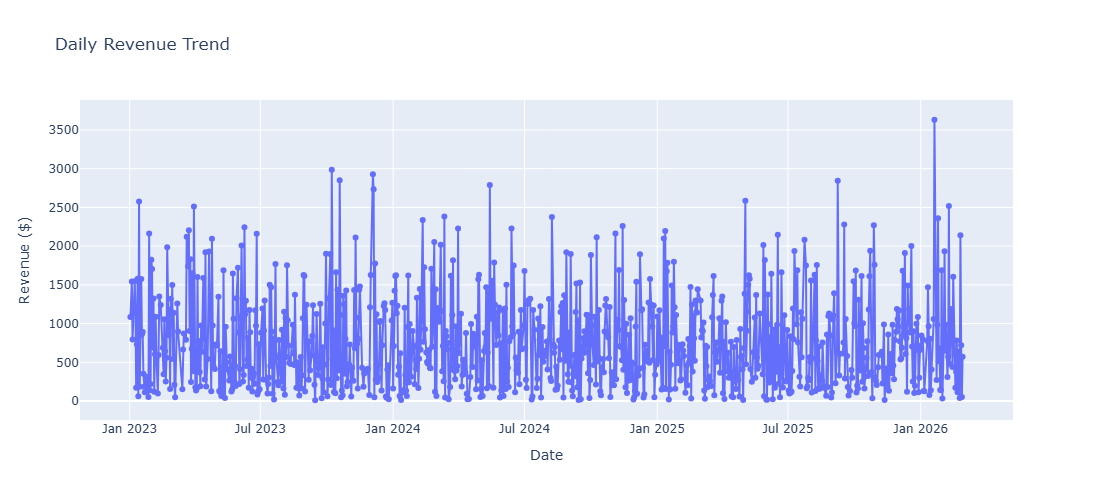

In [4]:
fig = px.line(
    daily_sales,
    x='date',
    y='total_revenue',
    title='Daily Revenue Trend',
    labels={'total_revenue': 'Revenue ($)', 'date': 'Date'},
    markers=True
)
fig.update_layout(hovermode='x unified', height=500)
fig.show()

In [5]:
inventory['date'] = pd.to_datetime(inventory['date'], errors='coerce')

drug_avg_stock = inventory.groupby('drug_name', as_index=False).agg({
    'quantity': 'mean',
    'usage_rate': 'mean'
}).round(2).sort_values('quantity', ascending=False)

print("\nAverage Stock by Drug:")
print(drug_avg_stock)


Average Stock by Drug:
      drug_name  quantity  usage_rate
9   Paracetamol    264.28       16.08
0   Amoxicillin    260.13       16.32
5     Ibuprofen    253.20       15.10
1       Aspirin    244.37       14.34
8    Omeprazole    243.01       14.59
4     Cetrizine    242.94       15.62
6      Losartan    238.66       14.80
2  Atorvastatin    238.16       14.71
7     Metformin    233.09       16.31
3  Azithromycin    230.29       15.53


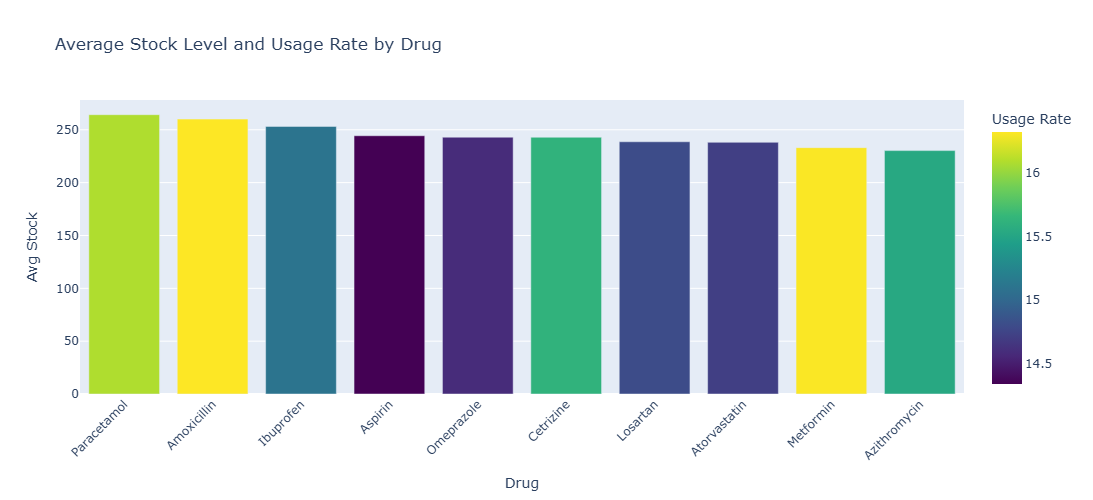

In [6]:
fig = px.bar(
    drug_avg_stock,
    x='drug_name',
    y='quantity',
    color='usage_rate',
    title='Average Stock Level and Usage Rate by Drug',
    labels={'quantity': 'Avg Stock', 'usage_rate': 'Usage Rate', 'drug_name': 'Drug'},
    color_continuous_scale='Viridis'
)
fig.update_layout(height=500, xaxis_tickangle=-45)
fig.show()

In [7]:
rx_dist = prescriptions['drug_prescribed'].value_counts().reset_index()
rx_dist.columns = ['drug', 'count']

print("\nPrescription Distribution:")
print(rx_dist)


Prescription Distribution:
           drug  count
0   Paracetamol    142
1  Azithromycin    142
2  Atorvastatin    134
3     Metformin    133
4   Amoxicillin    133
5     Cetrizine    128
6    Omeprazole    124
7     Ibuprofen    124
8      Losartan    121
9       Aspirin    119


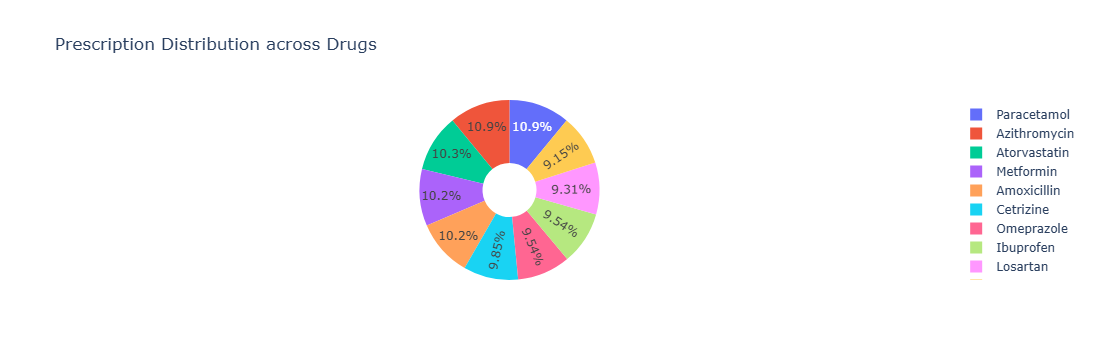

In [8]:
fig = px.pie(
    rx_dist,
    names='drug',
    values='count',
    title='Prescription Distribution across Drugs',
    hole=0.3
)
fig.show()

In [9]:
print("\nEmployee Performance Statistics:")
print(employees[['performance_score', 'attendance', 'workload']].describe().round(2))


Employee Performance Statistics:
       performance_score  attendance  workload
count            1200.00     1200.00   1200.00
mean               76.90       85.11     62.24
std                12.75        8.48     21.43
min                55.01       70.10     25.01
25%                65.85       78.14     43.79
50%                77.14       84.82     62.76
75%                87.77       92.04     80.40
max                99.00       99.95     99.76


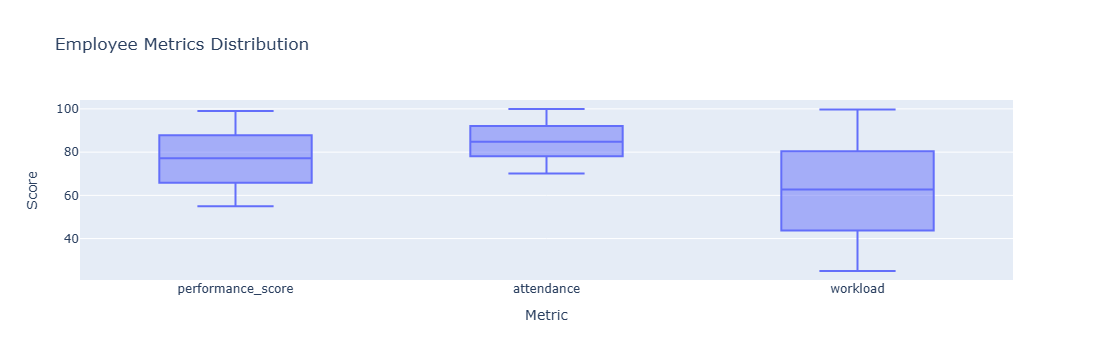

In [10]:
fig = px.box(
    employees,
    y=['performance_score', 'attendance', 'workload'],
    title='Employee Metrics Distribution',
    labels={'value': 'Score', 'variable': 'Metric'}
)
fig.show()

In [11]:
print("\nRevenue Analysis:")
print(f"Total Revenue: ${sales['revenue'].sum():,.2f}")
print(f"Average Transaction: ${sales['revenue'].mean():.2f}")
print(f"Median Transaction: ${sales['revenue'].median():.2f}")
print(f"Std Dev: ${sales['revenue'].std():.2f}")
print(f"Min: ${sales['revenue'].min():.2f}")
print(f"Max: ${sales['revenue'].max():.2f}")


Revenue Analysis:
Total Revenue: $720,424.30
Average Transaction: $360.21
Median Transaction: $283.51
Std Dev: $294.00
Min: $4.78
Max: $1259.65


## Key Insights

### Sales
- Revenue trend highlights demand movement over time
- Daily aggregation helps compare pharmacy performance across dates

### Inventory
- Average quantity by drug shows stocking priorities
- Usage rate helps identify fast-moving medications

### Prescriptions
- Distribution of prescribed drugs reveals treatment patterns

### Employees
- Performance, attendance, and workload distributions support workforce planning